# GAEZ 小麦分析（スリム版：補正なし＋耕地補正）

元の `GAEZ.ipynb` から、重複セル・途中確認・長い試行錯誤を削って、分析の主線だけを残したノートブックです。

**この版で残している2段階**

1. **耕地面積補正なし**: `attainable yield × グリッド全面積`  
2. **耕地面積補正あり**: `attainable yield × グリッド全面積 × cropland fraction`  

補正前を残すことで、「GAEZ が示す粗い潜在力」と「実際に耕地がある場所に絞った潜在力」を分けて見られます。

**単位の整理**

- `attainable yield`: kg/ha
- `grid area`: ha/grid
- `cropland fraction`: 0〜1
- `production`: tonnes

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

import rasterio
from rasterio.transform import from_bounds
from rasterio.features import rasterize


# ============================================================
# 基本設定
# ============================================================

BASE_DIR = Path(r"C:\masterresearch\Comparative_advantage")
GAEZ_DIR = BASE_DIR / "GAEZ"
CROP_DIR = GAEZ_DIR / "wheat"
HYDE_DIR = BASE_DIR / "HYDE3.4"

TARGET_YEAR = 2024
WHEAT_ITEM_CODE = 15

# GAEZ attainable yield: kg/ha
ATY_TIF = CROP_DIR / "GAEZ-V5.RES05-YLX.HP0120.AGERA5.HIST.WHE.HILM.tif"
ATY_NPY = CROP_DIR / "AttainableYield_wheat.npy"

# 各グリッドの面積: ha/grid
GRID_AREA_NPY = GAEZ_DIR / "grid_area_2160x4320_ha.npy"

# HYDE 3.4 cropland fraction: 0〜1
CROPLAND_NPY = (
    HYDE_DIR
    / "cropland_npys"
    / "yearly"
    / f"cropland_fraction_{TARGET_YEAR}.npy"
)

# cropland.nc は場所が揺れていたので候補を2つ置いておく
HYDE_NC_CANDIDATES = [
    HYDE_DIR / "cropland.nc",
    Path(r"C:\Users\tsuda\Downloads\cropland.nc"),
]

# FAOSTAT
FAOSTAT_CSV = (
    BASE_DIR
    / "wheat_production_2019"
    / "Production_Crops_Livestock_E_All_Data_(Normalized).csv"
)

GDP_CSV = BASE_DIR / "GDP_percapitaPPP.csv"

OUTPUT_DIR = CROP_DIR / "slim_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NATURAL_EARTH_URL = (
    "https://naturalearth.s3.amazonaws.com/"
    "110m_cultural/ne_110m_admin_0_countries.zip"
)

# GAEZ/HYDE の緯度方向が逆に見える場合だけ True にする
FLIP_CROPLAND_LAT = False

pd.options.display.float_format = "{:,.3f}".format

## 1. 入力データの準備

必要な `.npy` が既にあればそのまま使います。  
なければ、GAEZ の GeoTIFF や HYDE の NetCDF から最小限だけ作ります。

In [2]:
def save_gaez_tif_as_npy(tif_path, npy_path, meta_path=None, overwrite=False):
    """GAEZ GeoTIFF を読み、NoData を NaN にして .npy に保存する。"""
    tif_path = Path(tif_path)
    npy_path = Path(npy_path)

    if npy_path.exists() and not overwrite:
        print(f"Already exists: {npy_path}")
        return npy_path

    if not tif_path.exists():
        raise FileNotFoundError(f"GAEZ tif が見つかりません: {tif_path}")

    npy_path.parent.mkdir(parents=True, exist_ok=True)

    with rasterio.open(tif_path) as src:
        data = src.read(1).astype(np.float32)
        if src.nodata is not None:
            data = np.where(data == src.nodata, np.nan, data)

        if meta_path is not None:
            meta = {"transform": src.transform, "crs": src.crs}
            np.save(meta_path, meta, allow_pickle=True)

    np.save(npy_path, data)
    print(f"Saved: {npy_path}")
    return npy_path


def make_global_grid_area_ha(nlat=2160, nlon=4320, earth_radius_m=6_371_000):
    """全球の緯度経度グリッド面積を ha/grid で返す。"""
    dlon = 360 / nlon
    lat_edges = np.linspace(90, -90, nlat + 1)

    lat1 = np.deg2rad(lat_edges[:-1])
    lat2 = np.deg2rad(lat_edges[1:])
    dlon_rad = np.deg2rad(dlon)

    area_1d_m2 = (
        earth_radius_m ** 2
        * dlon_rad
        * np.abs(np.sin(lat1) - np.sin(lat2))
    )

    area_m2 = np.repeat(area_1d_m2[:, None], nlon, axis=1)
    return (area_m2 / 10_000).astype(np.float32)


def ensure_grid_area_npy(path, nlat=2160, nlon=4320):
    path = Path(path)
    if path.exists():
        print(f"Already exists: {path}")
        return path

    path.parent.mkdir(parents=True, exist_ok=True)
    grid_area_ha = make_global_grid_area_ha(nlat=nlat, nlon=nlon)
    np.save(path, grid_area_ha)
    print(f"Saved: {path}")
    return path


def extract_year(time_value):
    if hasattr(time_value, "year"):
        return int(time_value.year)
    return int(str(time_value).split("-")[0])


def ensure_cropland_fraction_npy(nc_candidates, npy_path, target_year, variable="cropland"):
    """HYDE cropland.nc から target_year の cropland fraction だけ保存する。"""
    npy_path = Path(npy_path)
    if npy_path.exists():
        print(f"Already exists: {npy_path}")
        return npy_path

    nc_path = next((Path(path) for path in nc_candidates if Path(path).exists()), None)
    if nc_path is None:
        raise FileNotFoundError(
            "cropland fraction npy がなく、cropland.nc も見つかりません。\n"
            f"探した場所: {nc_candidates}"
        )

    import xarray as xr

    with xr.open_dataset(nc_path, decode_times=True, mask_and_scale=True) as ds:
        if variable not in ds:
            raise KeyError(f"{variable!r} が NetCDF 内にありません。")

        years = np.array([extract_year(value) for value in ds["time"].values])
        matches = np.where(years == target_year)[0]
        if matches.size == 0:
            raise ValueError(f"{target_year}年の cropland データがありません。")

        fraction = ds[variable].isel(time=int(matches[0])).values.astype(np.float32)

    fraction = np.where(np.isfinite(fraction), fraction, np.nan)
    fraction = np.clip(fraction, 0.0, 1.0).astype(np.float32)

    npy_path.parent.mkdir(parents=True, exist_ok=True)
    np.save(npy_path, fraction)
    print(f"Saved: {npy_path}")
    return npy_path

In [3]:
# 必要な入力ファイルを用意する
save_gaez_tif_as_npy(
    tif_path=ATY_TIF,
    npy_path=ATY_NPY,
    meta_path=CROP_DIR / "Attainable_wheat_meta.npy",
)

ensure_grid_area_npy(GRID_AREA_NPY)

ensure_cropland_fraction_npy(
    nc_candidates=HYDE_NC_CANDIDATES,
    npy_path=CROPLAND_NPY,
    target_year=TARGET_YEAR,
)


# 読み込み
wheat_ATY = np.load(ATY_NPY, mmap_mode="r").astype(np.float32)
grid_area_ha = np.load(GRID_AREA_NPY, mmap_mode="r").astype(np.float32)
cropland_fraction = np.load(CROPLAND_NPY, mmap_mode="r").astype(np.float32)

if FLIP_CROPLAND_LAT:
    cropland_fraction = np.flipud(cropland_fraction)

print("Attainable yield shape :", wheat_ATY.shape)
print("Grid area shape        :", grid_area_ha.shape)
print("Cropland fraction shape:", cropland_fraction.shape)

if not (wheat_ATY.shape == grid_area_ha.shape == cropland_fraction.shape):
    raise ValueError(
        "3つの配列の shape が一致していません。\n"
        f"ATY      : {wheat_ATY.shape}\n"
        f"Area     : {grid_area_ha.shape}\n"
        f"Cropland : {cropland_fraction.shape}"
    )

height, width = wheat_ATY.shape

Already exists: C:\masterresearch\Comparative_advantage\GAEZ\wheat\AttainableYield_wheat.npy
Already exists: C:\masterresearch\Comparative_advantage\GAEZ\grid_area_2160x4320_ha.npy
Already exists: C:\masterresearch\Comparative_advantage\HYDE3.4\cropland_npys\yearly\cropland_fraction_2024.npy
Attainable yield shape : (2160, 4320)
Grid area shape        : (2160, 4320)
Cropland fraction shape: (2160, 4320)


## 2. 耕地面積補正なしの潜在生産量

まず、GAEZ の attainable yield をグリッド全面積に掛けます。  
これは「そのグリッド全体で小麦を作れる」とみなす粗い上限なので、耕地分布はまだ考慮していません。

\\[
\text{attainable production}_{grid}
=
\text{attainable yield}_{grid}
\times
\text{grid area}_{grid}
\\]

In [4]:
# inf などを NaN に寄せる
wheat_ATY = np.where(np.isfinite(wheat_ATY), wheat_ATY, np.nan)
grid_area_ha = np.where(np.isfinite(grid_area_ha), grid_area_ha, np.nan)
cropland_fraction = np.where(np.isfinite(cropland_fraction), cropland_fraction, np.nan)
cropland_fraction = np.clip(cropland_fraction, 0.0, 1.0)

# 耕地面積補正なし: kg/ha × ha/grid = kg/grid → tonnes/grid
valid_raw = (
    np.isfinite(wheat_ATY)
    & np.isfinite(grid_area_ha)
    & (wheat_ATY > 0)
    & (grid_area_ha > 0)
)

attainable_prod_tonnes = np.zeros(wheat_ATY.shape, dtype=np.float32)
attainable_prod_tonnes[valid_raw] = (
    wheat_ATY[valid_raw]
    * grid_area_ha[valid_raw]
    / 1000.0
)

print("Valid cells without cropland adjustment:", f"{np.sum(valid_raw):,}")
print(
    "Global attainable production without cropland adjustment [tonnes]:",
    f"{np.sum(attainable_prod_tonnes, dtype=np.float64):,.0f}",
)

Valid cells without cropland adjustment: 972,214
Global attainable production without cropland adjustment [tonnes]: 22,508,483,651


## 3. 耕地面積補正済みの潜在生産量

次に、HYDE の cropland fraction を掛けます。  
こちらは「各グリッド内の耕地部分だけで小麦を作る」とみなした潜在生産量です。

\\[
\text{cropland-adjusted production}_{grid}
=
\text{attainable yield}_{grid}
\times
\text{grid area}_{grid}
\times
\text{cropland fraction}_{grid}
\\]

In [5]:
valid_adjusted = (
    valid_raw
    & np.isfinite(cropland_fraction)
    & (cropland_fraction > 0)
)

cropland_area_ha = np.zeros(wheat_ATY.shape, dtype=np.float32)
cropland_area_ha[valid_adjusted] = (
    grid_area_ha[valid_adjusted]
    * cropland_fraction[valid_adjusted]
)

cropland_adjusted_prod_tonnes = np.zeros(wheat_ATY.shape, dtype=np.float32)
cropland_adjusted_prod_tonnes[valid_adjusted] = (
    wheat_ATY[valid_adjusted]
    * cropland_area_ha[valid_adjusted]
    / 1000.0
)

raw_total = np.sum(attainable_prod_tonnes, dtype=np.float64)
adjusted_total = np.sum(cropland_adjusted_prod_tonnes, dtype=np.float64)

print("Valid cells with cropland adjustment:", f"{np.sum(valid_adjusted):,}")
print("Total cropland area [ha]:", f"{np.sum(cropland_area_ha, dtype=np.float64):,.0f}")
print(
    "Global cropland-adjusted attainable production [tonnes]:",
    f"{adjusted_total:,.0f}",
)
print(
    "Adjusted / unadjusted:",
    f"{adjusted_total / raw_total:.3f}" if raw_total > 0 else "NA",
)

Valid cells with cropland adjustment: 719,609
Total cropland area [ha]: 1,190,566,106
Global cropland-adjusted attainable production [tonnes]: 5,859,493,261
Adjusted / unadjusted: 0.260


## 4. 国別に集計

Natural Earth の国境ポリゴンを GAEZ/HYDE と同じ `2160 × 4320` グリッドへ rasterize します。  
ここでは **補正なし** と **耕地補正あり** の両方を同じ国境ラスタで集計します。

In [6]:
world = gpd.read_file(NATURAL_EARTH_URL).to_crs("EPSG:4326")
world = world[world["ADMIN"] != "Antarctica"].copy().reset_index(drop=True)
world["country_id"] = np.arange(1, len(world) + 1, dtype=np.int32)

transform = from_bounds(-180, -90, 180, 90, width, height)

shapes = [
    (geometry, int(country_id))
    for geometry, country_id in zip(world.geometry, world["country_id"])
    if geometry is not None
]

country_raster = rasterize(
    shapes=shapes,
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype="int32",
)

rows = []
for _, country_row in world.iterrows():
    country_id = int(country_row["country_id"])
    country_mask = country_raster == country_id

    country_raw = country_mask & valid_raw
    country_adjusted_mask = country_mask & valid_adjusted

    grid_area_used_ha = np.sum(grid_area_ha[country_raw], dtype=np.float64)
    raw_prod_tonnes = np.sum(attainable_prod_tonnes[country_raw], dtype=np.float64)
    raw_mean_yield = (
        raw_prod_tonnes * 1000.0 / grid_area_used_ha
        if grid_area_used_ha > 0
        else np.nan
    )

    country_cropland_area_ha = np.sum(
        cropland_area_ha[country_adjusted_mask],
        dtype=np.float64,
    )
    adjusted_prod_tonnes = np.sum(
        cropland_adjusted_prod_tonnes[country_adjusted_mask],
        dtype=np.float64,
    )
    adjusted_mean_yield = (
        adjusted_prod_tonnes * 1000.0 / country_cropland_area_ha
        if country_cropland_area_ha > 0
        else np.nan
    )

    rows.append(
        {
            "country_id": country_id,
            "country": country_row["ADMIN"],
            "iso_a3": country_row["ISO_A3"],
            "continent": country_row["CONTINENT"],
            "subregion": country_row["SUBREGION"],
            "grid_area_used_ha": grid_area_used_ha,
            "attainable_production_tonnes": raw_prod_tonnes,
            "mean_attainable_yield_kg_ha": raw_mean_yield,
            "cropland_area_ha": country_cropland_area_ha,
            "cropland_adjusted_attainable_tonnes": adjusted_prod_tonnes,
            "mean_attainable_yield_on_cropland_kg_ha": adjusted_mean_yield,
        }
    )

country_summary = (
    pd.DataFrame(rows)
    .sort_values("attainable_production_tonnes", ascending=False)
    .reset_index(drop=True)
)

country_raw = country_summary[
    [
        "country_id",
        "country",
        "iso_a3",
        "continent",
        "subregion",
        "grid_area_used_ha",
        "attainable_production_tonnes",
        "mean_attainable_yield_kg_ha",
    ]
].copy()

country_adjusted = country_summary[
    [
        "country_id",
        "country",
        "iso_a3",
        "continent",
        "subregion",
        "cropland_area_ha",
        "cropland_adjusted_attainable_tonnes",
        "mean_attainable_yield_on_cropland_kg_ha",
    ]
].copy()

out_summary_csv = OUTPUT_DIR / f"wheat_country_attainable_summary_{TARGET_YEAR}.csv"
out_raw_csv = OUTPUT_DIR / f"wheat_attainable_by_country_no_cropland_adjustment_{TARGET_YEAR}.csv"
out_adjusted_csv = OUTPUT_DIR / f"wheat_cropland_adjusted_attainable_by_country_{TARGET_YEAR}.csv"

country_summary.to_csv(out_summary_csv, index=False, encoding="utf-8-sig")
country_raw.to_csv(out_raw_csv, index=False, encoding="utf-8-sig")
country_adjusted.to_csv(out_adjusted_csv, index=False, encoding="utf-8-sig")

print("Saved summary:", out_summary_csv)
print("Saved no-adjustment:", out_raw_csv)
print("Saved cropland-adjusted:", out_adjusted_csv)

display(
    country_summary[
        [
            "country",
            "iso_a3",
            "attainable_production_tonnes",
            "cropland_adjusted_attainable_tonnes",
            "cropland_area_ha",
        ]
    ].head(20)
)

Saved summary: C:\masterresearch\Comparative_advantage\GAEZ\wheat\slim_outputs\wheat_country_attainable_summary_2024.csv
Saved no-adjustment: C:\masterresearch\Comparative_advantage\GAEZ\wheat\slim_outputs\wheat_attainable_by_country_no_cropland_adjustment_2024.csv
Saved cropland-adjusted: C:\masterresearch\Comparative_advantage\GAEZ\wheat\slim_outputs\wheat_cropland_adjusted_attainable_by_country_2024.csv


,country,iso_a3,attainable_production_tonnes,cropland_adjusted_attainable_tonnes,cropland_area_ha
0,United States of America,USA,"4,322,322,829.621","1,196,977,599.167","160,069,915.028"
1,Russia,RUS,"2,538,617,051.144","827,656,548.556","123,079,487.471"
2,China,CHN,"1,734,623,299.015","550,105,214.461","131,242,616.314"
3,Australia,AUS,"1,481,248,657.631","167,415,912.156","31,213,899.534"
4,Argentina,ARG,"1,052,792,530.785","277,882,471.505","44,568,852.262"
5,Canada,CAN,"973,941,152.204","219,471,052.891","37,747,069.684"
6,Kazakhstan,KAZ,"793,836,419.589","125,741,519.820","29,747,825.769"
7,India,IND,"664,927,819.587","437,594,102.179","127,231,730.958"
8,Ukraine,UKR,"469,150,644.189","278,662,359.078","32,262,057.432"
9,South Africa,ZAF,"437,955,583.837","59,649,896.365","12,241,877.199"


## 5. FAOSTAT 実生産量と比較

FAOSTAT の国名は Natural Earth と完全一致しないので、よく使う国名だけ対応表で寄せます。  
ここでも **補正なし** と **耕地補正あり** を同じ表で比較します。

In [7]:
NAME_MAP = {
    "United States": "United States of America",
    "United States of America": "United States of America",
    "Russian Federation": "Russia",
    "China, mainland": "China",
    "Iran (Islamic Republic of)": "Iran",
    "Türkiye": "Turkey",
    "Viet Nam": "Vietnam",
    "Bolivia (Plurinational State of)": "Bolivia",
    "Venezuela (Bolivarian Republic of)": "Venezuela",
    "Syrian Arab Republic": "Syria",
    "Republic of Korea": "South Korea",
    "Democratic People's Republic of Korea": "North Korea",
    "Lao People's Democratic Republic": "Laos",
    "United Republic of Tanzania": "Tanzania",
    "Côte d'Ivoire": "Ivory Coast",
    "Congo": "Republic of the Congo",
    "Republic of Moldova": "Moldova",
    "Netherlands (Kingdom of the)": "Netherlands",
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "Sudan (former)": "Sudan",
}

faostat = pd.read_csv(FAOSTAT_CSV, low_memory=False)

item_code = pd.to_numeric(faostat["Item Code"], errors="coerce")
year = pd.to_numeric(faostat["Year"], errors="coerce")

wheat_actual = faostat[
    (item_code == WHEAT_ITEM_CODE)
    & (year == TARGET_YEAR)
    & faostat["Element"].str.contains("Production", case=False, na=False)
].copy()

wheat_actual["actual_production_tonnes"] = pd.to_numeric(
    wheat_actual["Value"],
    errors="coerce",
)

print("FAOSTAT unit check")
display(wheat_actual["Unit"].value_counts(dropna=False))

wheat_actual["country"] = wheat_actual["Area"].replace(NAME_MAP)

actual_country = (
    wheat_actual
    .groupby("country", as_index=False)
    .agg(actual_production_tonnes=("actual_production_tonnes", "sum"))
)

df_corr = country_summary.merge(actual_country, on="country", how="inner")

df_corr = df_corr[
    np.isfinite(df_corr["actual_production_tonnes"])
    & np.isfinite(df_corr["attainable_production_tonnes"])
    & (df_corr["actual_production_tonnes"] > 0)
    & (df_corr["attainable_production_tonnes"] > 0)
].copy()

df_corr["log_attainable"] = np.log10(df_corr["attainable_production_tonnes"])
df_corr["log_actual"] = np.log10(df_corr["actual_production_tonnes"])
df_corr["actual_div_attainable"] = (
    df_corr["actual_production_tonnes"]
    / df_corr["attainable_production_tonnes"]
)

has_adjusted = (
    np.isfinite(df_corr["cropland_adjusted_attainable_tonnes"])
    & (df_corr["cropland_adjusted_attainable_tonnes"] > 0)
)

df_corr["log_adjusted_attainable"] = np.nan
df_corr.loc[has_adjusted, "log_adjusted_attainable"] = np.log10(
    df_corr.loc[has_adjusted, "cropland_adjusted_attainable_tonnes"]
)

df_corr["actual_div_adjusted_attainable"] = np.nan
df_corr.loc[has_adjusted, "actual_div_adjusted_attainable"] = (
    df_corr.loc[has_adjusted, "actual_production_tonnes"]
    / df_corr.loc[has_adjusted, "cropland_adjusted_attainable_tonnes"]
)

df_corr["region"] = df_corr["continent"].fillna("Unknown")
df_corr.loc[df_corr["iso_a3"] == "RUS", "region"] = "Europe"

df_corr_adjusted = df_corr[has_adjusted].copy()

out_merged_csv = OUTPUT_DIR / f"wheat_attainable_vs_actual_both_versions_{TARGET_YEAR}.csv"
df_corr.to_csv(out_merged_csv, index=False, encoding="utf-8-sig")

print("Matched countries, no adjustment:", len(df_corr))
print("Matched countries, cropland-adjusted:", len(df_corr_adjusted))
print("Saved:", out_merged_csv)

display(
    df_corr[
        [
            "country",
            "iso_a3",
            "region",
            "attainable_production_tonnes",
            "cropland_adjusted_attainable_tonnes",
            "actual_production_tonnes",
            "actual_div_attainable",
            "actual_div_adjusted_attainable",
        ]
    ]
    .sort_values("actual_production_tonnes", ascending=False)
    .head(30)
)


def correlation_dict(data, x_col, log_x_col):
    pearson_raw, pearson_raw_p = pearsonr(data[x_col], data["actual_production_tonnes"])
    spearman_raw, spearman_raw_p = spearmanr(data[x_col], data["actual_production_tonnes"])
    pearson_log, pearson_log_p = pearsonr(data[log_x_col], data["log_actual"])
    spearman_log, spearman_log_p = spearmanr(data[log_x_col], data["log_actual"])

    return {
        "pearson_raw": pearson_raw,
        "pearson_raw_p": pearson_raw_p,
        "spearman_raw": spearman_raw,
        "spearman_raw_p": spearman_raw_p,
        "pearson_log": pearson_log,
        "pearson_log_p": pearson_log_p,
        "spearman_log": spearman_log,
        "spearman_log_p": spearman_log_p,
    }


corr_no_adjustment = correlation_dict(
    df_corr,
    "attainable_production_tonnes",
    "log_attainable",
)
corr_cropland_adjusted = correlation_dict(
    df_corr_adjusted,
    "cropland_adjusted_attainable_tonnes",
    "log_adjusted_attainable",
)

print("========== Correlation: no cropland adjustment ==========")
print(
    f"Pearson raw    : r = {corr_no_adjustment['pearson_raw']:.3f}, "
    f"p = {corr_no_adjustment['pearson_raw_p']:.3g}"
)
print(
    f"Spearman raw   : rho = {corr_no_adjustment['spearman_raw']:.3f}, "
    f"p = {corr_no_adjustment['spearman_raw_p']:.3g}"
)
print(
    f"Pearson log10  : r = {corr_no_adjustment['pearson_log']:.3f}, "
    f"p = {corr_no_adjustment['pearson_log_p']:.3g}"
)
print(
    f"Spearman log10 : rho = {corr_no_adjustment['spearman_log']:.3f}, "
    f"p = {corr_no_adjustment['spearman_log_p']:.3g}"
)

print("\n========== Correlation: cropland-adjusted ==========")
print(
    f"Pearson raw    : r = {corr_cropland_adjusted['pearson_raw']:.3f}, "
    f"p = {corr_cropland_adjusted['pearson_raw_p']:.3g}"
)
print(
    f"Spearman raw   : rho = {corr_cropland_adjusted['spearman_raw']:.3f}, "
    f"p = {corr_cropland_adjusted['spearman_raw_p']:.3g}"
)
print(
    f"Pearson log10  : r = {corr_cropland_adjusted['pearson_log']:.3f}, "
    f"p = {corr_cropland_adjusted['pearson_log_p']:.3g}"
)
print(
    f"Spearman log10 : rho = {corr_cropland_adjusted['spearman_log']:.3f}, "
    f"p = {corr_cropland_adjusted['spearman_log_p']:.3g}"
)

FAOSTAT unit check


Unit
t    156
Name: count, dtype: int64

Matched countries, no adjustment: 118
Matched countries, cropland-adjusted: 117
Saved: C:\masterresearch\Comparative_advantage\GAEZ\wheat\slim_outputs\wheat_attainable_vs_actual_both_versions_2024.csv


,country,iso_a3,region,attainable_production_tonnes,cropland_adjusted_attainable_tonnes,actual_production_tonnes,actual_div_attainable,actual_div_adjusted_attainable
2,China,CHN,Asia,"1,734,623,299.015","550,105,214.461","280,205,000.000",0.162,0.509
7,India,IND,Asia,"664,927,819.587","437,594,102.179","113,292,368.000",0.170,0.259
1,Russia,RUS,Europe,"2,538,617,051.144","827,656,548.556","82,588,000.000",0.033,0.100
0,United States of America,USA,North America,"4,322,322,829.621","1,196,977,599.167","53,650,020.000",0.012,0.045
5,Canada,CAN,North America,"973,941,152.204","219,471,052.891","35,938,839.000",0.037,0.164
3,Australia,AUS,Oceania,"1,481,248,657.631","167,415,912.156","34,110,000.000",0.023,0.204
22,Pakistan,PAK,Asia,"192,182,708.028","99,163,768.382","31,814,444.000",0.166,0.321
17,France,-99,Europe,"233,315,387.613","88,263,728.990","26,606,940.000",0.114,0.301
8,Ukraine,UKR,Europe,"469,150,644.189","278,662,359.078","22,441,110.000",0.048,0.081
15,Turkey,TUR,Asia,"249,245,398.956","91,546,271.087","20,800,000.000",0.083,0.227


========== Correlation: no cropland adjustment ==========
Pearson raw    : r = 0.567, p = 2.28e-11
Spearman raw   : rho = 0.687, p = 9.38e-18
Pearson log10  : r = 0.705, p = 4.83e-19
Spearman log10 : rho = 0.687, p = 9.38e-18

========== Correlation: cropland-adjusted ==========
Pearson raw    : r = 0.642, p = 5.99e-15
Spearman raw   : rho = 0.840, p = 2.19e-32
Pearson log10  : r = 0.836, p = 8.71e-32
Spearman log10 : rho = 0.840, p = 2.19e-32


## 6. 可視化

補正なしと耕地補正ありを並べて見ます。  
45度線より上は、実生産量がその潜在生産量指標より大きい国です。

c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


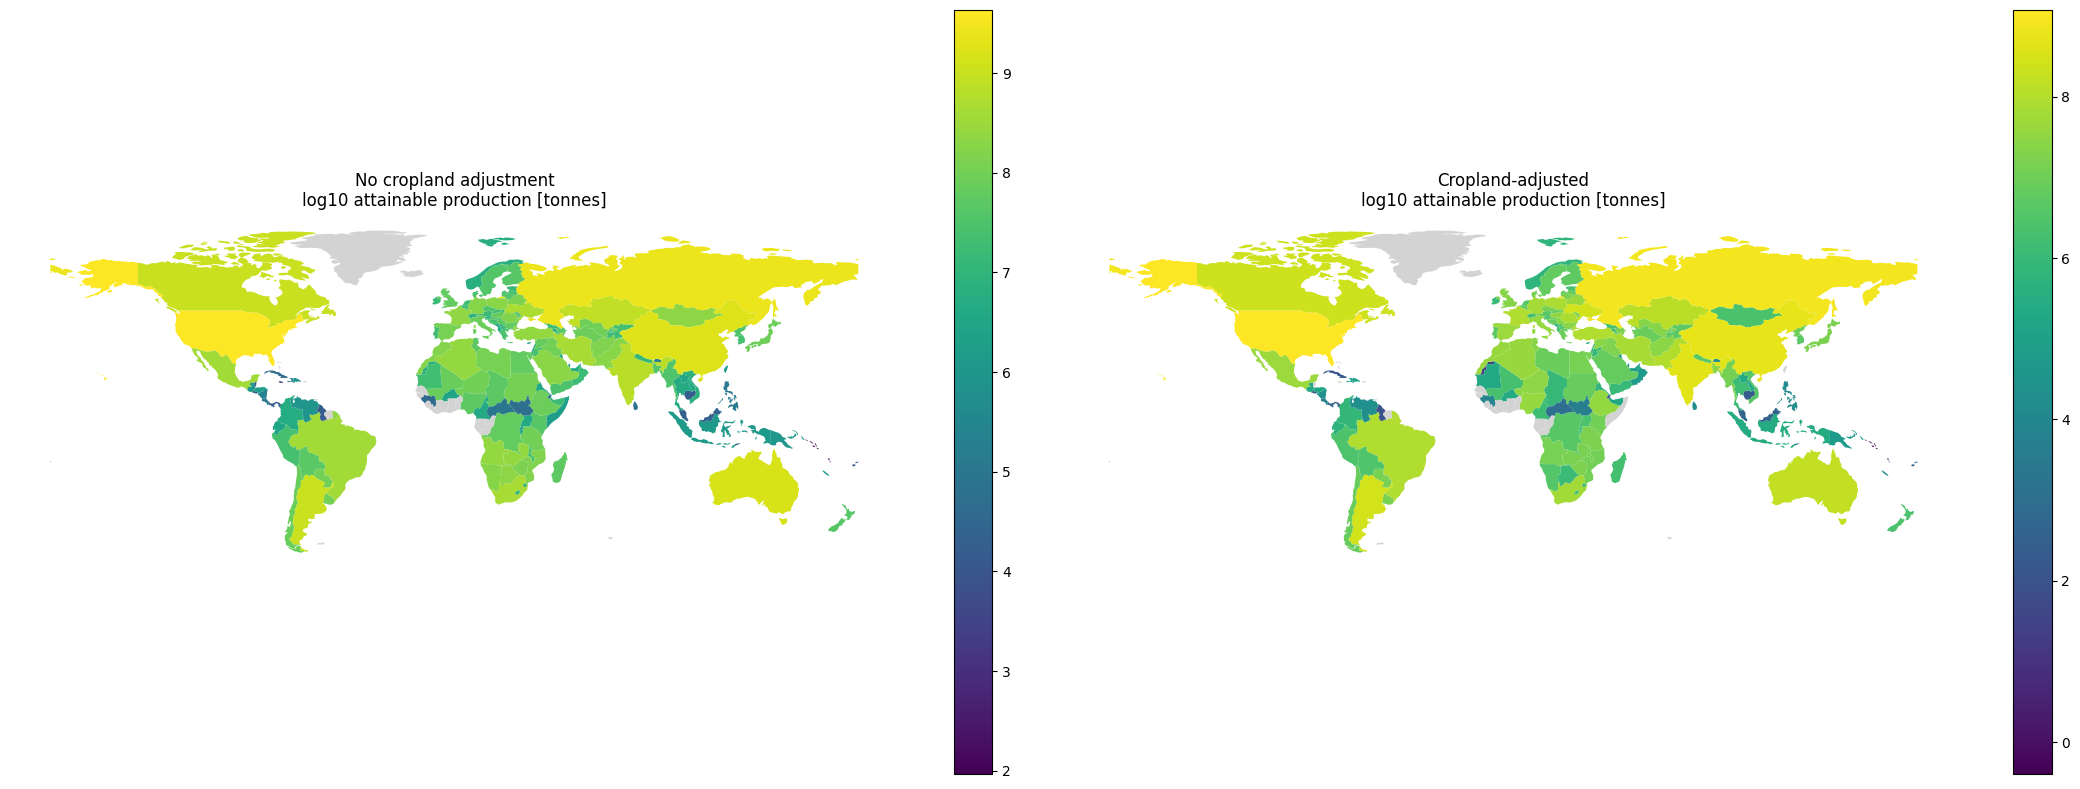

Saved: C:\masterresearch\Comparative_advantage\GAEZ\wheat\slim_outputs\wheat_attainable_map_comparison_2024.png


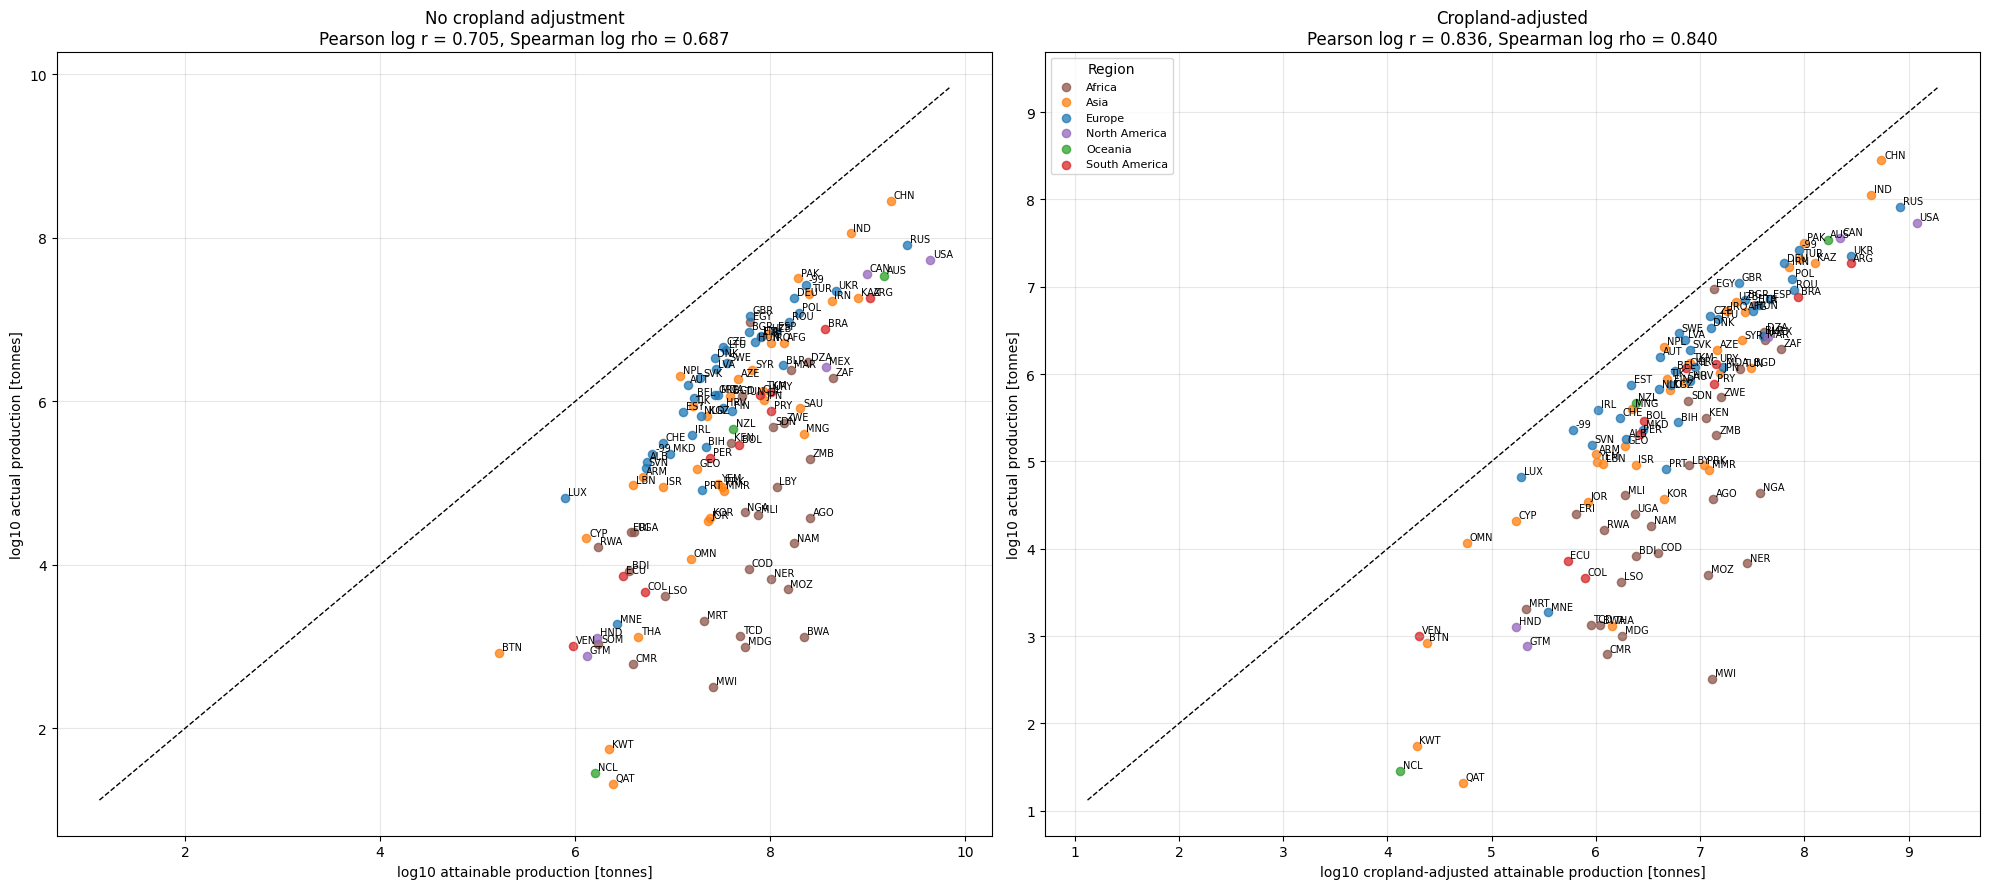

Saved: C:\masterresearch\Comparative_advantage\GAEZ\wheat\slim_outputs\wheat_attainable_vs_actual_comparison_2024.png


In [8]:
world_map = world.merge(
    country_summary[
        [
            "country_id",
            "attainable_production_tonnes",
            "cropland_adjusted_attainable_tonnes",
        ]
    ],
    on="country_id",
    how="left",
)

world_map["log10_attainable"] = np.where(
    world_map["attainable_production_tonnes"] > 0,
    np.log10(world_map["attainable_production_tonnes"]),
    np.nan,
)
world_map["log10_adjusted_attainable"] = np.where(
    world_map["cropland_adjusted_attainable_tonnes"] > 0,
    np.log10(world_map["cropland_adjusted_attainable_tonnes"]),
    np.nan,
)

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

world_map.plot(
    column="log10_attainable",
    cmap="viridis",
    legend=True,
    ax=axes[0],
    missing_kwds={"color": "lightgrey", "label": "No data / zero"},
)
axes[0].set_title("No cropland adjustment\nlog10 attainable production [tonnes]")
axes[0].axis("off")

world_map.plot(
    column="log10_adjusted_attainable",
    cmap="viridis",
    legend=True,
    ax=axes[1],
    missing_kwds={"color": "lightgrey", "label": "No data / zero"},
)
axes[1].set_title("Cropland-adjusted\nlog10 attainable production [tonnes]")
axes[1].axis("off")

plt.tight_layout()
out_map_compare = OUTPUT_DIR / f"wheat_attainable_map_comparison_{TARGET_YEAR}.png"
plt.savefig(out_map_compare, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", out_map_compare)


region_colors = {
    "Europe": "tab:blue",
    "Asia": "tab:orange",
    "Oceania": "tab:green",
    "South America": "tab:red",
    "North America": "tab:purple",
    "Africa": "tab:brown",
}


def plot_actual_vs_potential(ax, data, x_col, y_col, title, xlabel):
    for region in sorted(data["region"].dropna().unique()):
        sub = data[data["region"] == region]
        ax.scatter(
            sub[x_col],
            sub[y_col],
            s=35,
            alpha=0.75,
            label=region,
            color=region_colors.get(region),
        )

    for _, row in data.iterrows():
        ax.annotate(
            row["iso_a3"],
            (row[x_col], row[y_col]),
            xytext=(2, 2),
            textcoords="offset points",
            fontsize=7,
        )

    min_val = min(data[x_col].min(), data[y_col].min())
    max_val = max(data[x_col].max(), data[y_col].max())
    pad = 0.2
    ax.plot(
        [min_val - pad, max_val + pad],
        [min_val - pad, max_val + pad],
        "--",
        linewidth=1,
        color="black",
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel("log10 actual production [tonnes]")
    ax.set_title(title)
    ax.grid(alpha=0.3)


fig, axes = plt.subplots(1, 2, figsize=(20, 9))

plot_actual_vs_potential(
    axes[0],
    df_corr,
    "log_attainable",
    "log_actual",
    (
        "No cropland adjustment\n"
        f"Pearson log r = {corr_no_adjustment['pearson_log']:.3f}, "
        f"Spearman log rho = {corr_no_adjustment['spearman_log']:.3f}"
    ),
    "log10 attainable production [tonnes]",
)

plot_actual_vs_potential(
    axes[1],
    df_corr_adjusted,
    "log_adjusted_attainable",
    "log_actual",
    (
        "Cropland-adjusted\n"
        f"Pearson log r = {corr_cropland_adjusted['pearson_log']:.3f}, "
        f"Spearman log rho = {corr_cropland_adjusted['spearman_log']:.3f}"
    ),
    "log10 cropland-adjusted attainable production [tonnes]",
)

axes[1].legend(title="Region", fontsize=8, loc="best")
plt.tight_layout()

out_scatter_compare = OUTPUT_DIR / f"wheat_attainable_vs_actual_comparison_{TARGET_YEAR}.png"
plt.savefig(out_scatter_compare, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", out_scatter_compare)

## 7. 任意：GDP per capita を足して見る

ここは補助分析です。`GDP_percapitaPPP.csv` がある場合だけ、達成率と GDP per capita の関係を描きます。  
達成率も **補正なし** と **耕地補正あり** を並べます。

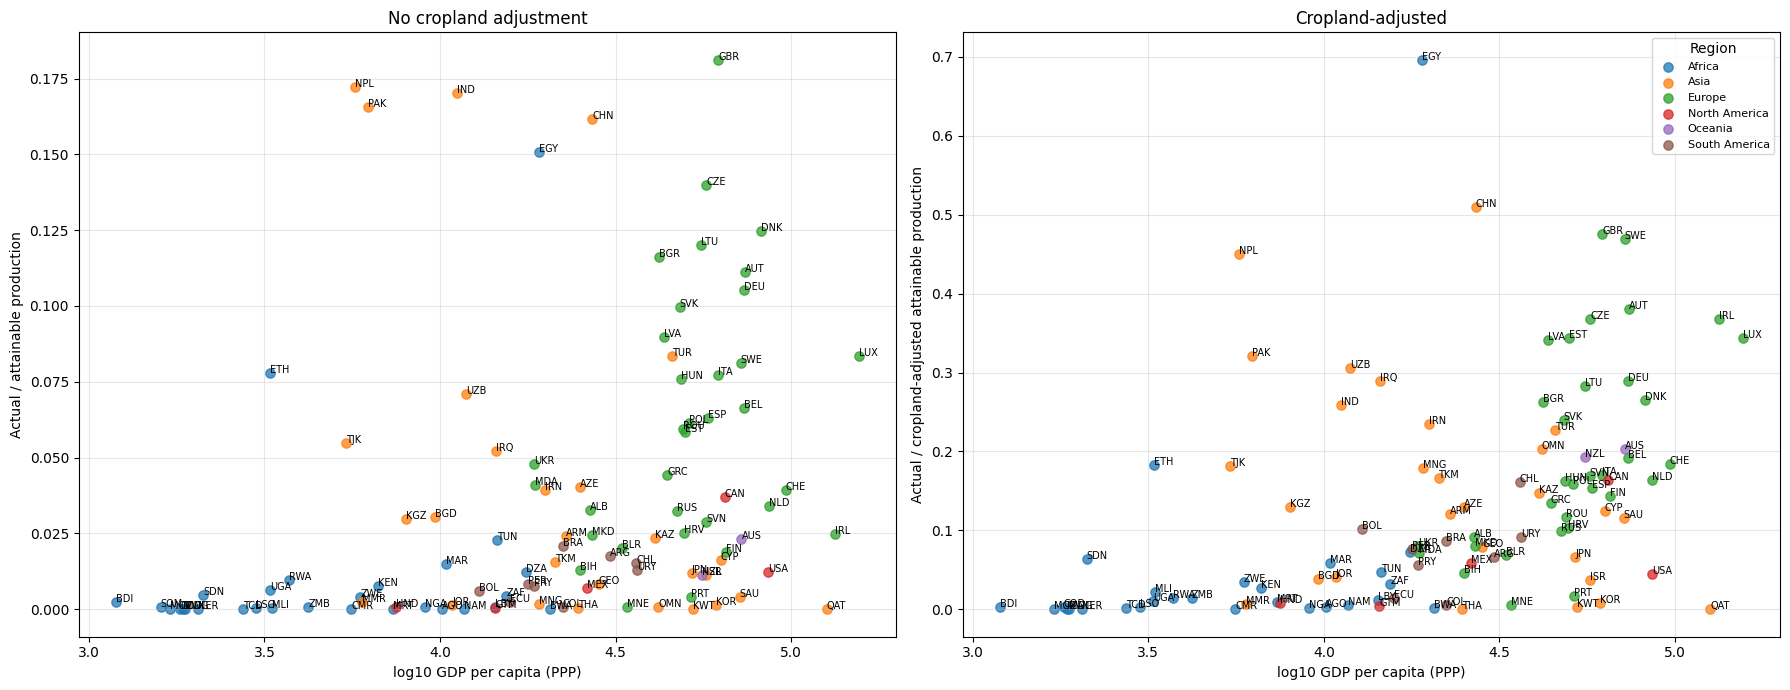

Saved: C:\masterresearch\Comparative_advantage\GAEZ\wheat\slim_outputs\wheat_attainment_vs_gdp_comparison_2024.png
Regression: no cropland adjustment
                            OLS Regression Results                            
Dep. Variable:             log_actual   R-squared:                       0.578
Model:                            OLS   Adj. R-squared:                  0.570
Method:                 Least Squares   F-statistic:                     80.39
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           7.86e-22
Time:                        18:27:07   Log-Likelihood:                -146.73
No. Observations:                 107   AIC:                             299.5
Df Residuals:                     104   BIC:                             307.5
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|  

In [9]:
if GDP_CSV.exists():
    gdp = pd.read_csv(GDP_CSV, skiprows=4)
    gdp = gdp[["Country Code", str(TARGET_YEAR)]].rename(
        columns={"Country Code": "iso_a3", str(TARGET_YEAR): "GDP_PPP"}
    )
    gdp["GDP_PPP"] = pd.to_numeric(gdp["GDP_PPP"], errors="coerce")

    gdp_df = df_corr.merge(gdp, on="iso_a3", how="left").dropna(subset=["GDP_PPP"])
    gdp_df["log_gdp"] = np.log10(gdp_df["GDP_PPP"])

    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True)

    panels = [
        (
            axes[0],
            "actual_div_attainable",
            "No cropland adjustment",
            "Actual / attainable production",
        ),
        (
            axes[1],
            "actual_div_adjusted_attainable",
            "Cropland-adjusted",
            "Actual / cropland-adjusted attainable production",
        ),
    ]

    for ax, y_col, title, ylabel in panels:
        plot_data = gdp_df.dropna(subset=[y_col])

        for region in sorted(plot_data["region"].dropna().unique()):
            sub = plot_data[plot_data["region"] == region]
            ax.scatter(
                sub["log_gdp"],
                sub[y_col],
                s=45,
                alpha=0.75,
                label=region,
            )

        for _, row in plot_data.iterrows():
            ax.text(row["log_gdp"], row[y_col], row["iso_a3"], fontsize=7)

        ax.set_title(title)
        ax.set_xlabel("log10 GDP per capita (PPP)")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)

    axes[1].legend(title="Region", fontsize=8)
    plt.tight_layout()

    out_gdp = OUTPUT_DIR / f"wheat_attainment_vs_gdp_comparison_{TARGET_YEAR}.png"
    plt.savefig(out_gdp, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", out_gdp)

    try:
        import statsmodels.formula.api as smf

        print("Regression: no cropland adjustment")
        model_raw = smf.ols(
            "log_actual ~ log_attainable + log_gdp",
            data=gdp_df,
        ).fit(cov_type="HC3")
        print(model_raw.summary())

        print("\nRegression: cropland-adjusted")
        model_adjusted = smf.ols(
            "log_actual ~ log_adjusted_attainable + log_gdp",
            data=gdp_df.dropna(subset=["log_adjusted_attainable"]),
        ).fit(cov_type="HC3")
        print(model_adjusted.summary())
    except ImportError:
        print("statsmodels がないため回帰はスキップしました。")
else:
    print(f"GDP CSV が見つからないためスキップしました: {GDP_CSV}")

## 結果の読み方

- `attainable_production_tonnes` は、耕地面積補正なしの粗い潜在生産量です。
- `cropland_adjusted_attainable_tonnes` は、HYDE cropland fraction を掛けた潜在生産量です。
- `actual_div_attainable` は、実生産量 ÷ 補正なし潜在生産量です。
- `actual_div_adjusted_attainable` は、実生産量 ÷ 耕地補正済み潜在生産量です。
- どちらの達成率も「効率」そのものではありません。作付面積、作物選択、灌漑、貿易、統計定義、国境・グリッド誤差の影響を受けます。
- `region` は Natural Earth の `CONTINENT` を使っています。元ノートと合わせて Russia は Europe 扱いにしています。

## 8. CPY -> ATY -> cropland-adjusted reduction

This final block visualizes how country-level potential wheat production changes across three stages.

1. **CPY / Climate potential**: climate potential yield x grid area
2. **ATY / Attainable**: attainable yield x grid area
3. **Cropland-adjusted**: attainable yield x grid area x cropland fraction

The key outputs are:

- global bar chart: total decrease by stage
- country bar chart: absolute production by stage for top countries
- country line chart: remaining share when CPY is set to 100%
- country loss chart: countries with the largest total reduction

CPY grid matches ATY grid: (2160, 4320)
Saved: C:\masterresearch\Comparative_advantage\GAEZ\wheat\slim_outputs\wheat_cpy_aty_cropland_stage_by_country_2024.csv


,country,iso_a3,climate_potential_tonnes,attainable_production_tonnes,cropland_adjusted_attainable_tonnes,attainable_share_of_climate,cropland_share_of_attainable,cropland_share_of_climate,loss_total_pct
4,United States of America,USA,"6,904,370,716.472","4,322,322,829.621","1,196,977,599.167",0.626,0.277,0.173,82.663
139,China,CHN,"4,074,839,152.405","1,734,623,299.015","550,105,214.461",0.426,0.317,0.135,86.500
18,Russia,RUS,"3,715,188,579.348","2,538,617,051.144","827,656,548.556",0.683,0.326,0.223,77.722
137,Australia,AUS,"2,511,433,235.165","1,481,248,657.631","167,415,912.156",0.590,0.113,0.067,93.334
3,Canada,CAN,"1,727,669,986.273","973,941,152.204","219,471,052.891",0.564,0.225,0.127,87.297
5,Kazakhstan,KAZ,"1,627,337,102.371","793,836,419.589","125,741,519.820",0.488,0.158,0.077,92.273
9,Argentina,ARG,"1,472,901,664.274","1,052,792,530.785","277,882,471.505",0.715,0.264,0.189,81.134
107,Iran,IRN,"1,236,440,345.233","424,229,654.777","71,443,562.497",0.343,0.168,0.058,94.222
27,Mexico,MEX,"1,186,126,916.987","371,376,795.422","44,997,196.816",0.313,0.121,0.038,96.206
98,India,IND,"1,130,767,748.354","664,927,819.587","437,594,102.179",0.588,0.658,0.387,61.301


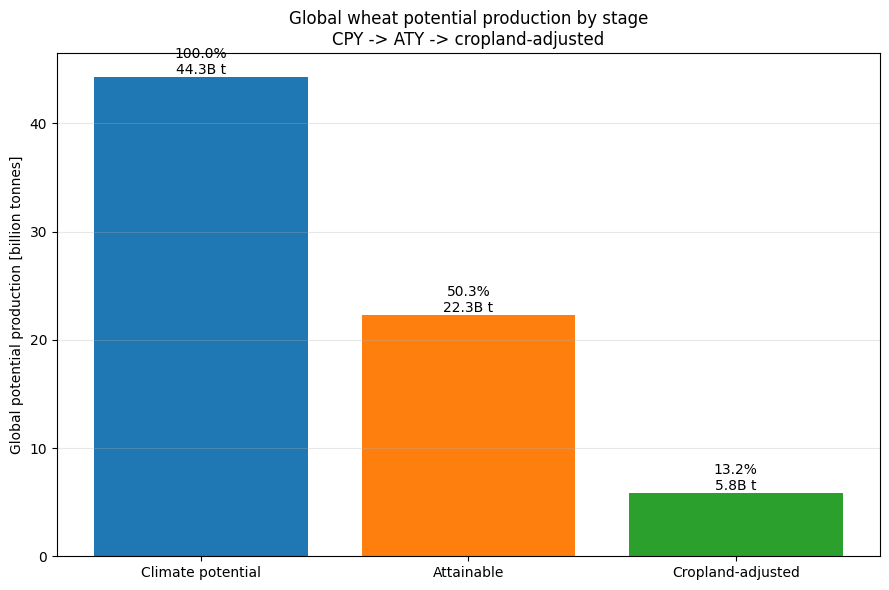

Saved: C:\masterresearch\Comparative_advantage\GAEZ\wheat\slim_outputs\wheat_global_cpy_aty_cropland_reduction_2024.png


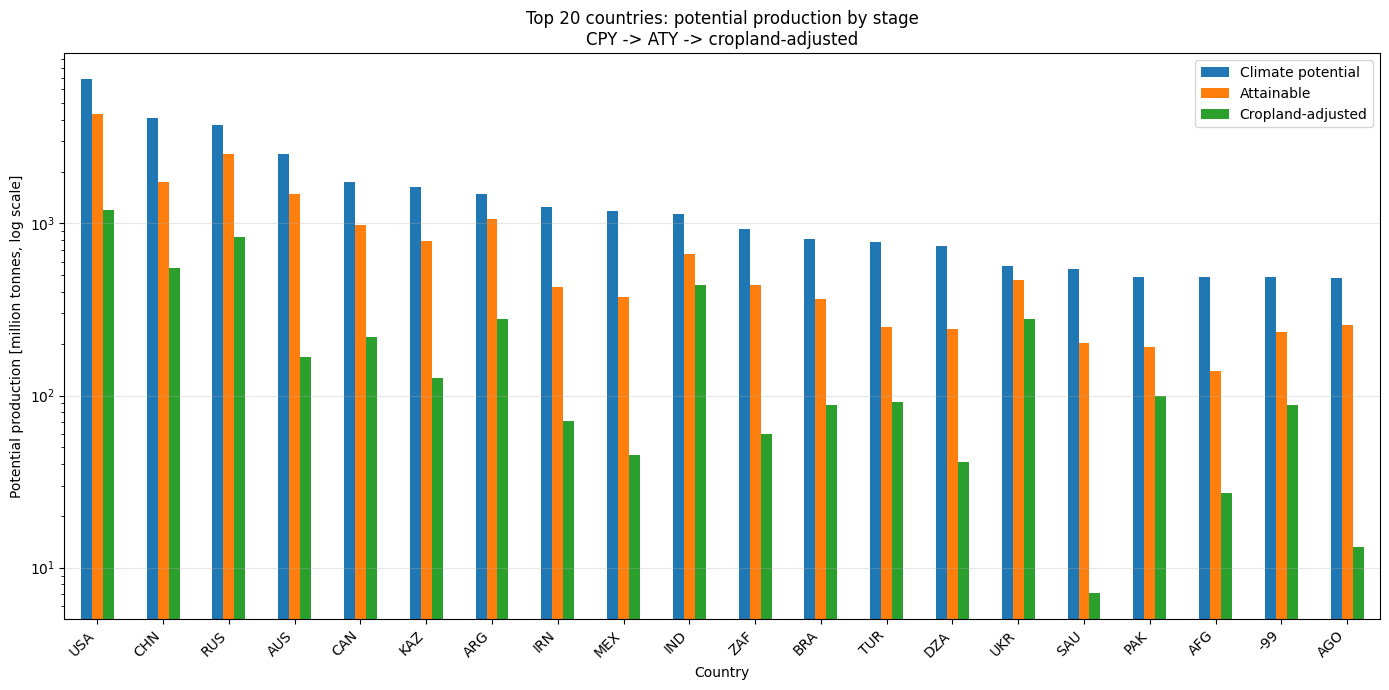

Saved: C:\masterresearch\Comparative_advantage\GAEZ\wheat\slim_outputs\wheat_country_cpy_aty_cropland_absolute_top20_2024.png


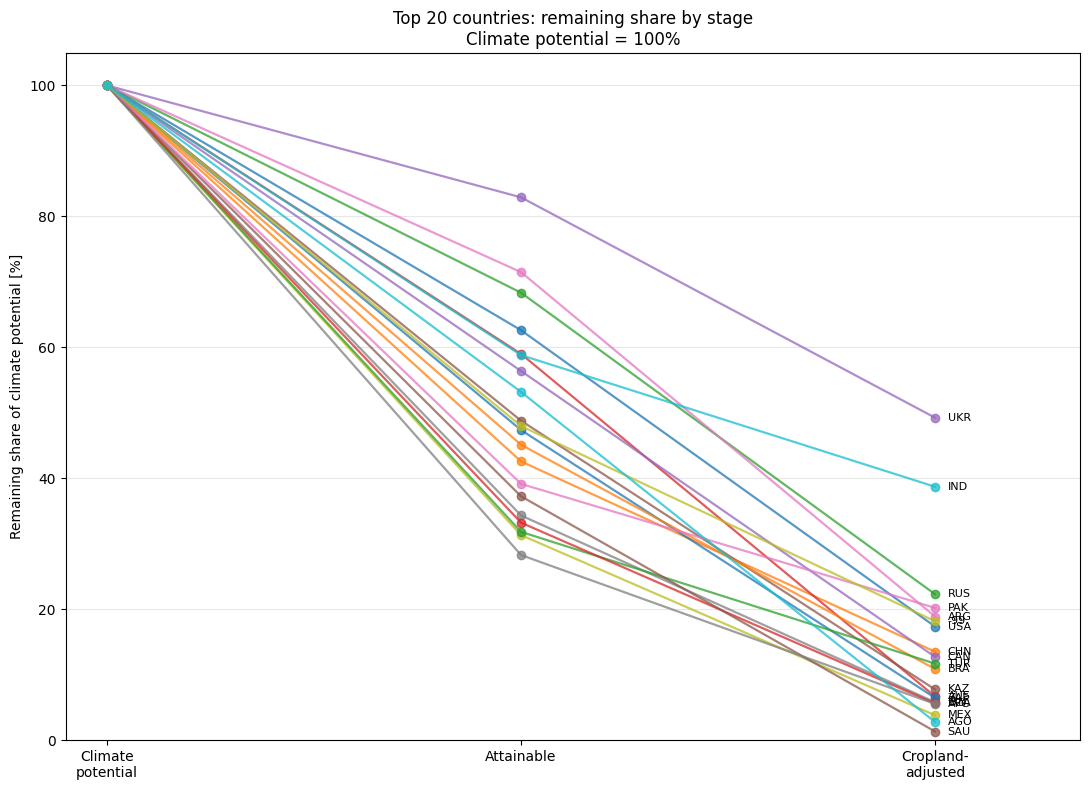

Saved: C:\masterresearch\Comparative_advantage\GAEZ\wheat\slim_outputs\wheat_country_cpy_aty_cropland_remaining_share_top20_2024.png


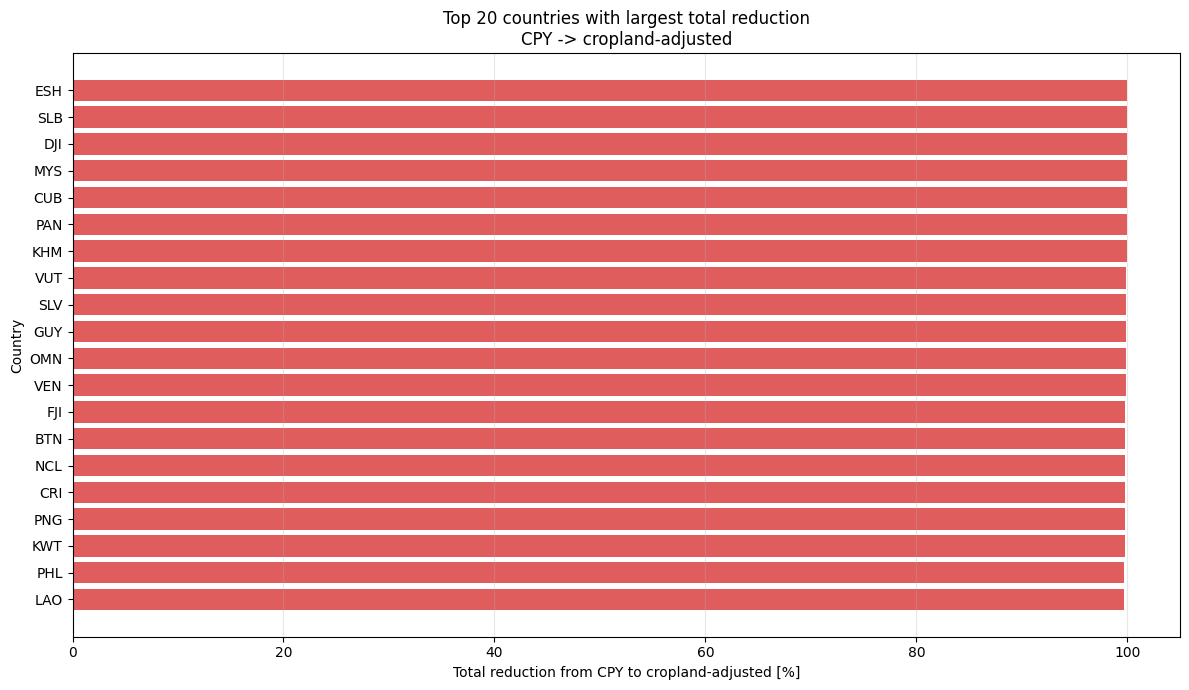

Saved: C:\masterresearch\Comparative_advantage\GAEZ\wheat\slim_outputs\wheat_country_cpy_to_cropland_loss_top20_2024.png


In [10]:
# ============================================================
# CPY -> ATY -> cropland-adjusted
# Visualize country-level potential production reductions
# ============================================================

TOP_N = 20

# Climate potential yield: kg/ha
CPY_TIF = CROP_DIR / "GAEZ-V5.RES02-YLD.HP0120.AGERA5.HIST.WHEA.HILM.tif"
CPY_NPY = CROP_DIR / "CPY_wheat.npy"

if not CPY_NPY.exists():
    save_gaez_tif_as_npy(
        tif_path=CPY_TIF,
        npy_path=CPY_NPY,
        meta_path=CROP_DIR / "CPY_meta.npy",
    )

wheat_CPY = np.load(CPY_NPY, mmap_mode="r").astype(np.float32)
wheat_CPY = np.where(np.isfinite(wheat_CPY), wheat_CPY, np.nan)

cpy_height, cpy_width = wheat_CPY.shape

# If CPY and ATY grids differ, build area and country raster for CPY grid.
if wheat_CPY.shape == grid_area_ha.shape:
    cpy_grid_area_ha = grid_area_ha
    cpy_country_raster = country_raster
    print("CPY grid matches ATY grid:", wheat_CPY.shape)
else:
    print("CPY grid differs from ATY grid.")
    print("CPY shape:", wheat_CPY.shape)
    print("ATY shape:", grid_area_ha.shape)
    print("Rebuilding grid area and country raster for CPY grid.")

    cpy_grid_area_ha = make_global_grid_area_ha(
        nlat=cpy_height,
        nlon=cpy_width,
    )

    cpy_transform = from_bounds(
        -180,
        -90,
        180,
        90,
        cpy_width,
        cpy_height,
    )

    cpy_country_raster = rasterize(
        shapes=shapes,
        out_shape=(cpy_height, cpy_width),
        transform=cpy_transform,
        fill=0,
        dtype="int32",
    )


# 1. Climate potential production
valid_cpy = (
    np.isfinite(wheat_CPY)
    & np.isfinite(cpy_grid_area_ha)
    & (wheat_CPY > 0)
    & (cpy_grid_area_ha > 0)
)

climate_potential_prod_tonnes = np.zeros(
    wheat_CPY.shape,
    dtype=np.float32,
)

climate_potential_prod_tonnes[valid_cpy] = (
    wheat_CPY[valid_cpy]
    * cpy_grid_area_ha[valid_cpy]
    / 1000.0
)


# 2. Aggregate CPY production by country
climate_rows = []

for _, country_row in world.iterrows():
    country_id = int(country_row["country_id"])
    country_cpy = (cpy_country_raster == country_id) & valid_cpy

    cpy_area_ha = np.sum(
        cpy_grid_area_ha[country_cpy],
        dtype=np.float64,
    )

    climate_potential_tonnes = np.sum(
        climate_potential_prod_tonnes[country_cpy],
        dtype=np.float64,
    )

    mean_climate_potential_yield_kg_ha = (
        climate_potential_tonnes * 1000.0 / cpy_area_ha
        if cpy_area_ha > 0
        else np.nan
    )

    climate_rows.append(
        {
            "country_id": country_id,
            "country": country_row["ADMIN"],
            "iso_a3": country_row["ISO_A3"],
            "climate_grid_area_ha": cpy_area_ha,
            "climate_potential_tonnes": climate_potential_tonnes,
            "mean_climate_potential_yield_kg_ha":
                mean_climate_potential_yield_kg_ha,
        }
    )

country_climate = pd.DataFrame(climate_rows)


# 3. Merge with existing ATY and cropland-adjusted country summary
stage_df = country_climate.merge(
    country_summary[
        [
            "country_id",
            "country",
            "iso_a3",
            "continent",
            "subregion",
            "attainable_production_tonnes",
            "cropland_adjusted_attainable_tonnes",
        ]
    ],
    on=["country_id", "country", "iso_a3"],
    how="left",
)

stage_df = stage_df[
    np.isfinite(stage_df["climate_potential_tonnes"])
    & np.isfinite(stage_df["attainable_production_tonnes"])
    & np.isfinite(stage_df["cropland_adjusted_attainable_tonnes"])
    & (stage_df["climate_potential_tonnes"] > 0)
    & (stage_df["attainable_production_tonnes"] > 0)
    & (stage_df["cropland_adjusted_attainable_tonnes"] > 0)
].copy()

stage_df["region"] = stage_df["continent"].fillna("Unknown")
stage_df.loc[stage_df["iso_a3"] == "RUS", "region"] = "Europe"


# 4. Remaining shares and losses
stage_df["attainable_share_of_climate"] = (
    stage_df["attainable_production_tonnes"]
    / stage_df["climate_potential_tonnes"]
)

stage_df["cropland_share_of_attainable"] = (
    stage_df["cropland_adjusted_attainable_tonnes"]
    / stage_df["attainable_production_tonnes"]
)

stage_df["cropland_share_of_climate"] = (
    stage_df["cropland_adjusted_attainable_tonnes"]
    / stage_df["climate_potential_tonnes"]
)

stage_df["loss_climate_to_attainable_pct"] = (
    1.0 - stage_df["attainable_share_of_climate"]
) * 100

stage_df["loss_attainable_to_cropland_pct"] = (
    1.0 - stage_df["cropland_share_of_attainable"]
) * 100

stage_df["loss_total_pct"] = (
    1.0 - stage_df["cropland_share_of_climate"]
) * 100


out_stage_csv = OUTPUT_DIR / f"wheat_cpy_aty_cropland_stage_by_country_{TARGET_YEAR}.csv"
stage_df.to_csv(out_stage_csv, index=False, encoding="utf-8-sig")
print("Saved:", out_stage_csv)

display(
    stage_df[
        [
            "country",
            "iso_a3",
            "climate_potential_tonnes",
            "attainable_production_tonnes",
            "cropland_adjusted_attainable_tonnes",
            "attainable_share_of_climate",
            "cropland_share_of_attainable",
            "cropland_share_of_climate",
            "loss_total_pct",
        ]
    ]
    .sort_values("climate_potential_tonnes", ascending=False)
    .head(TOP_N)
)


# Figure 1: global totals by stage
global_values = pd.Series(
    {
        "Climate potential": stage_df["climate_potential_tonnes"].sum(),
        "Attainable": stage_df["attainable_production_tonnes"].sum(),
        "Cropland-adjusted": stage_df["cropland_adjusted_attainable_tonnes"].sum(),
    }
)

global_share = global_values / global_values.iloc[0] * 100

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(
    global_values.index,
    global_values.values / 1e9,
    color=["tab:blue", "tab:orange", "tab:green"],
)

for bar, share in zip(bars, global_share.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{share:.1f}%\n{bar.get_height():,.1f}B t",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_ylabel("Global potential production [billion tonnes]")
ax.set_title(
    "Global wheat potential production by stage\n"
    "CPY -> ATY -> cropland-adjusted"
)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

out_global_stage = OUTPUT_DIR / f"wheat_global_cpy_aty_cropland_reduction_{TARGET_YEAR}.png"
plt.savefig(out_global_stage, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", out_global_stage)


# Figure 2: absolute production by stage for top countries
top_stage = (
    stage_df
    .sort_values("climate_potential_tonnes", ascending=False)
    .head(TOP_N)
    .copy()
)

absolute_plot = (
    top_stage
    .set_index("iso_a3")[
        [
            "climate_potential_tonnes",
            "attainable_production_tonnes",
            "cropland_adjusted_attainable_tonnes",
        ]
    ]
    / 1e6
)

absolute_plot.columns = [
    "Climate potential",
    "Attainable",
    "Cropland-adjusted",
]

fig, ax = plt.subplots(figsize=(14, 7))
absolute_plot.plot(kind="bar", ax=ax)
ax.set_yscale("log")
ax.set_ylabel("Potential production [million tonnes, log scale]")
ax.set_xlabel("Country")
ax.set_title(
    f"Top {TOP_N} countries: potential production by stage\n"
    "CPY -> ATY -> cropland-adjusted"
)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

out_absolute_stage = OUTPUT_DIR / f"wheat_country_cpy_aty_cropland_absolute_top{TOP_N}_{TARGET_YEAR}.png"
plt.savefig(out_absolute_stage, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", out_absolute_stage)


# Figure 3: remaining share when CPY is set to 100%
fig, ax = plt.subplots(figsize=(11, 8))

x = np.array([0, 1, 2])
x_labels = [
    "Climate\npotential",
    "Attainable",
    "Cropland-\nadjusted",
]

for _, row in top_stage.iterrows():
    y = np.array(
        [
            100.0,
            row["attainable_share_of_climate"] * 100,
            row["cropland_share_of_climate"] * 100,
        ]
    )

    ax.plot(
        x,
        y,
        marker="o",
        linewidth=1.6,
        alpha=0.75,
    )

    ax.text(
        x[-1] + 0.03,
        y[-1],
        row["iso_a3"],
        va="center",
        fontsize=8,
    )

ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_ylabel("Remaining share of climate potential [%]")
ax.set_title(
    f"Top {TOP_N} countries: remaining share by stage\n"
    "Climate potential = 100%"
)
ax.set_xlim(-0.1, 2.35)
ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

out_share_stage = OUTPUT_DIR / f"wheat_country_cpy_aty_cropland_remaining_share_top{TOP_N}_{TARGET_YEAR}.png"
plt.savefig(out_share_stage, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", out_share_stage)


# Figure 4: countries with largest total reduction
loss_top = (
    stage_df
    .sort_values("loss_total_pct", ascending=False)
    .head(TOP_N)
    .copy()
)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(
    loss_top["iso_a3"],
    loss_top["loss_total_pct"],
    color="tab:red",
    alpha=0.75,
)
ax.invert_yaxis()
ax.set_xlabel("Total reduction from CPY to cropland-adjusted [%]")
ax.set_ylabel("Country")
ax.set_title(
    f"Top {TOP_N} countries with largest total reduction\n"
    "CPY -> cropland-adjusted"
)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()

out_loss_stage = OUTPUT_DIR / f"wheat_country_cpy_to_cropland_loss_top{TOP_N}_{TARGET_YEAR}.png"
plt.savefig(out_loss_stage, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", out_loss_stage)

GloFAS 2020 visual check
plotting shape after downsampling: (540, 1080); DS=4
source directory: C:\masterresearch\Comparative_advantage\GloFAS\processed_5min
threshold >   1 m3/s | reliable plotted cells=30,954 | distance q95=3,799.4 km
threshold >  10 m3/s | reliable plotted cells=12,620 | distance q95=5,424.7 km
threshold > 100 m3/s | reliable plotted cells=4,323 | distance q95=6,511.6 km


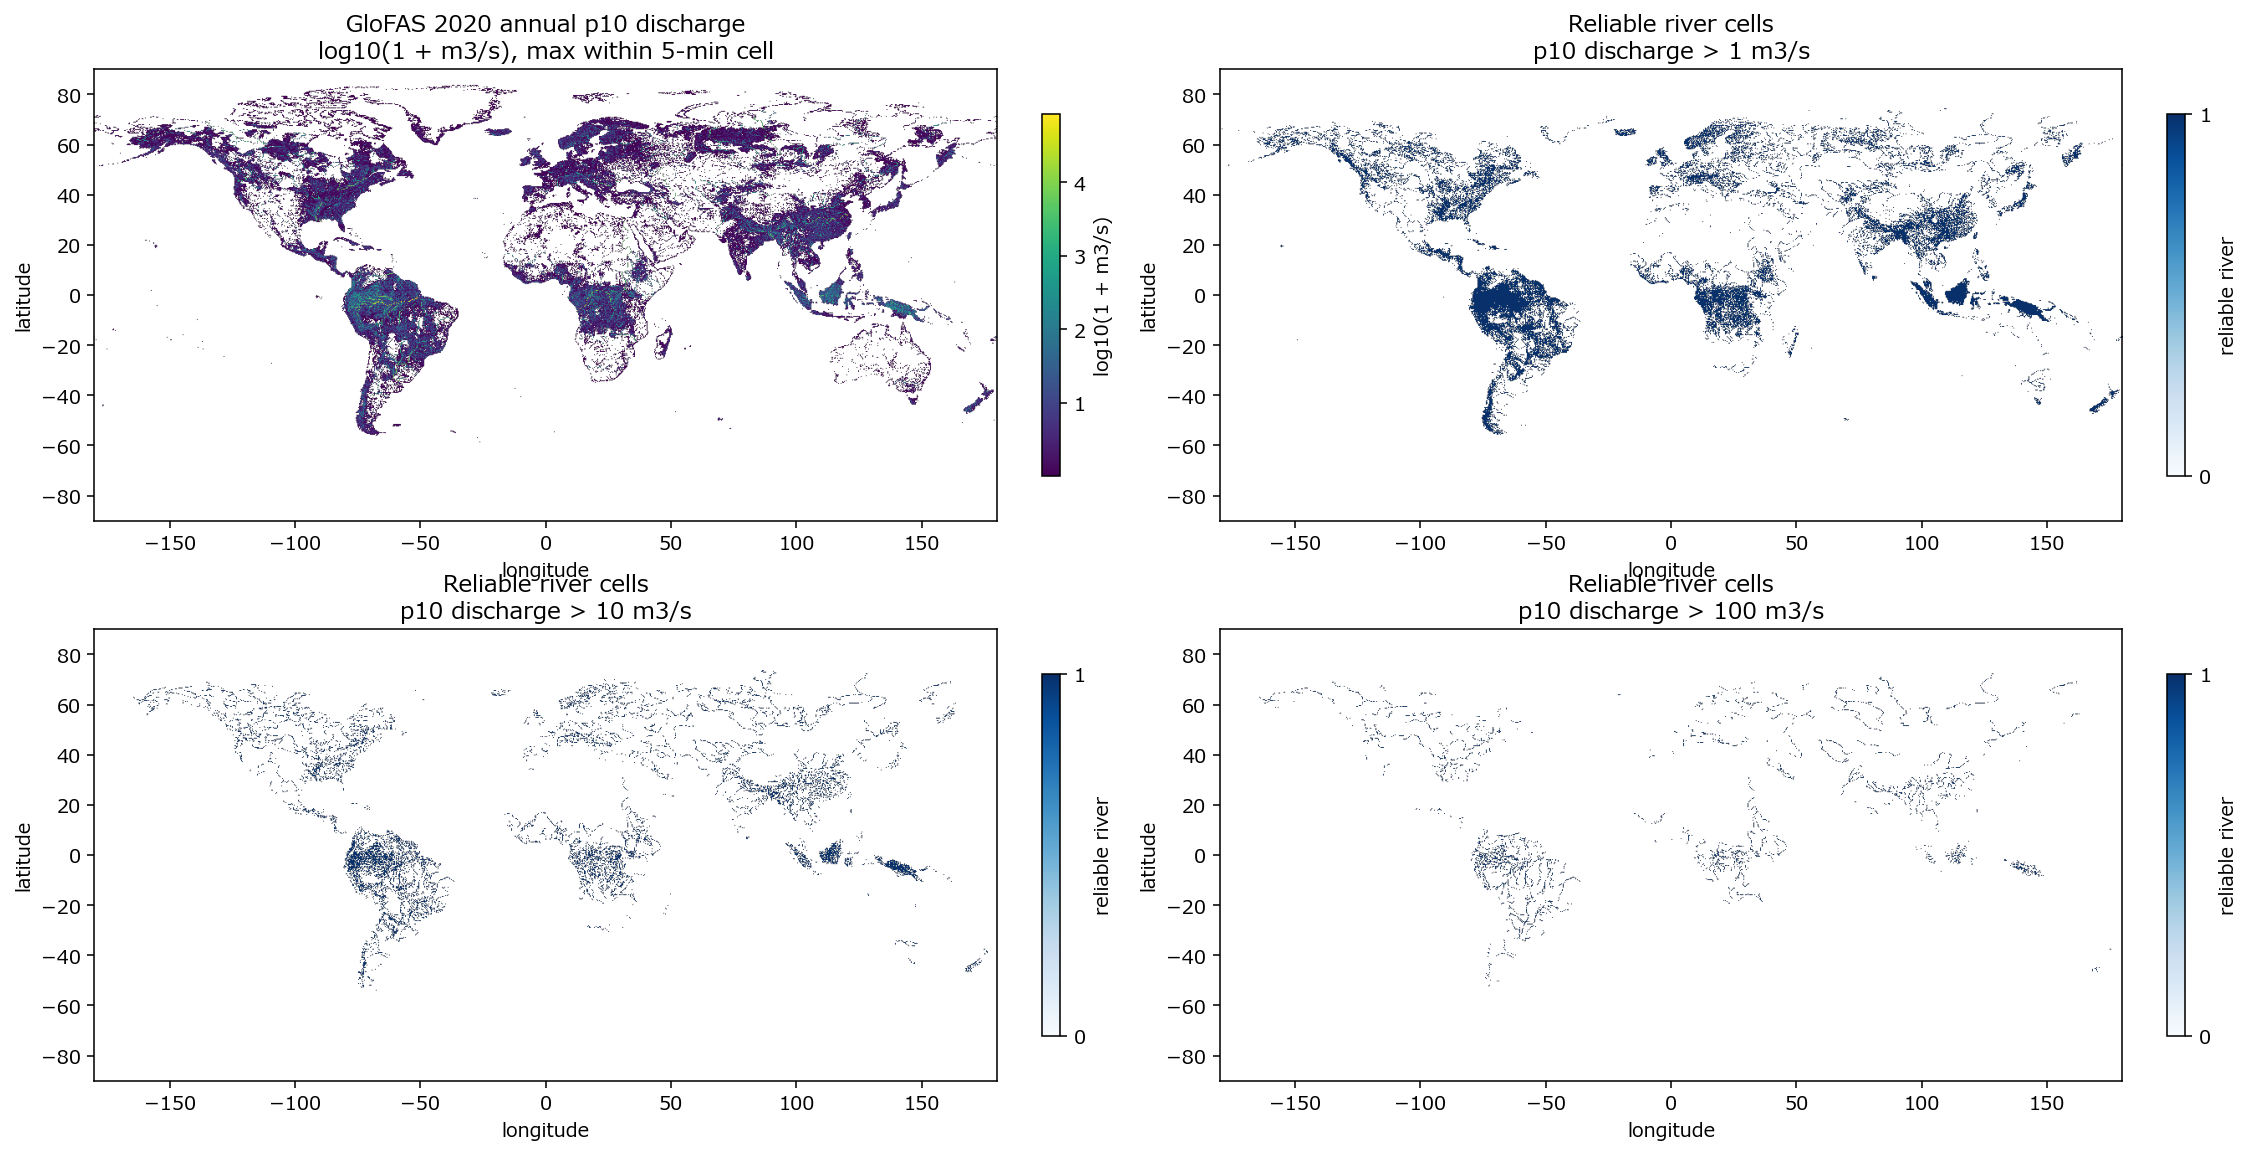

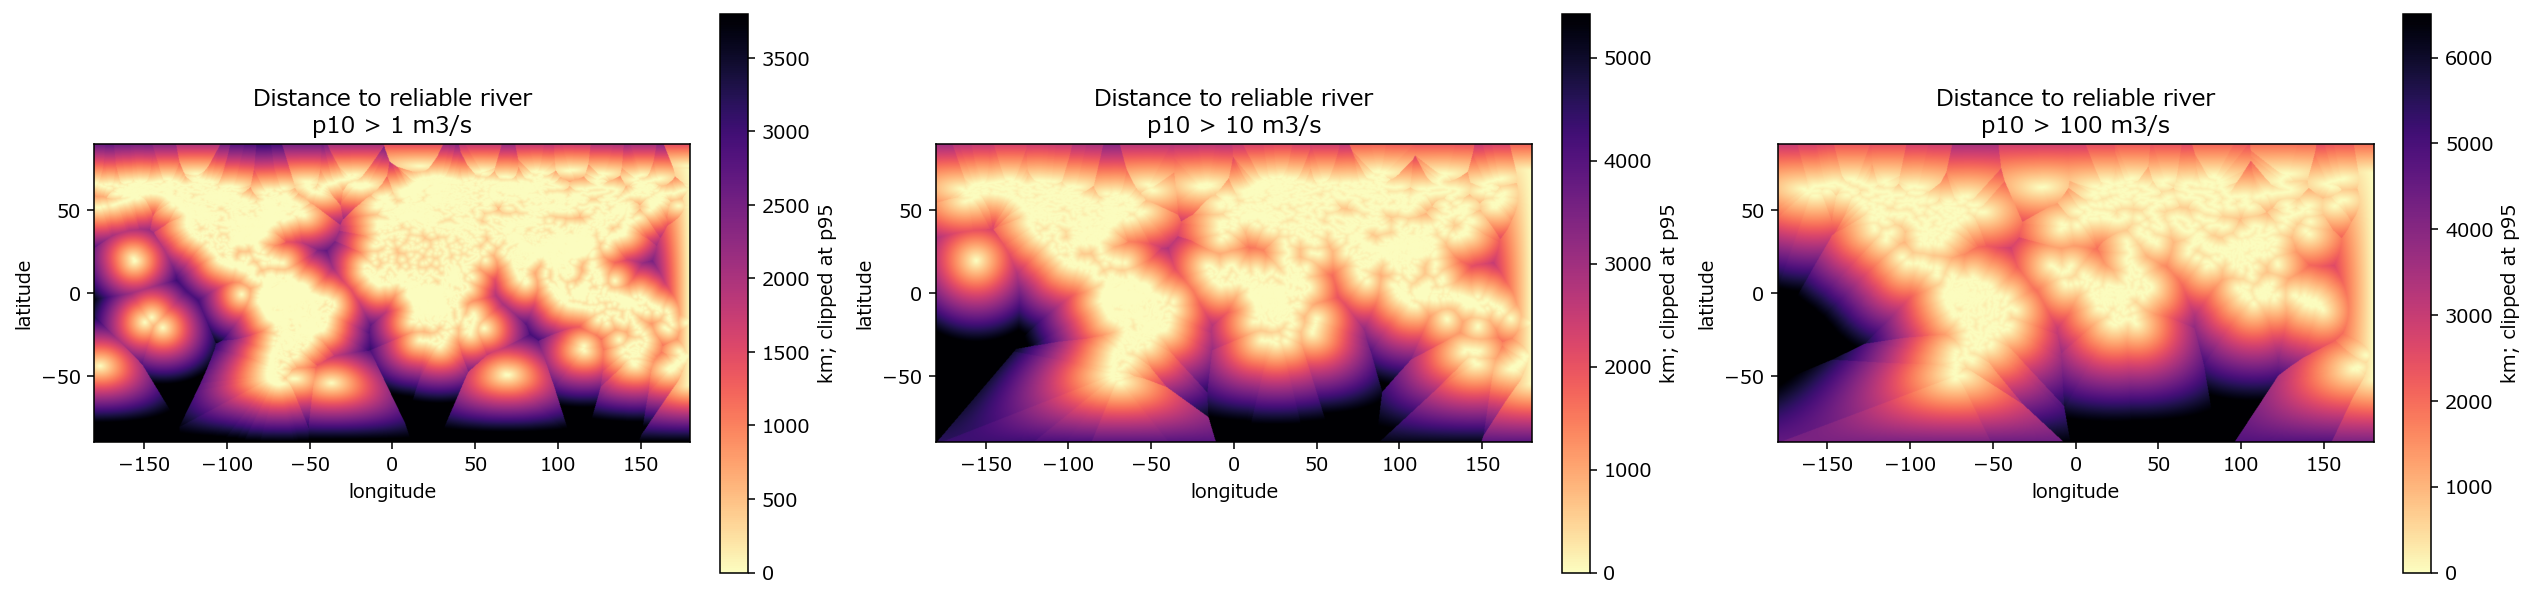

In [11]:
# ============================================================
# Visual check: GloFAS reliable river / distance rasters
#
# Uses 2020 annual p10 discharge generated from GloFAS daily river discharge.
# DS=4 means plotting every 4th cell for quick visual inspection.
# Set DS=1 if you want full-resolution plotting inside the notebook.
# ============================================================

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


GLOFAS_PROCESSED_DIR = Path(r"C:\masterresearch\Comparative_advantage\GloFAS\processed_5min")
THRESHOLDS_M3S = [1, 10, 100]
DS = 4
EXTENT = [-180, 180, -90, 90]

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = ["Meiryo", "Yu Gothic", "DejaVu Sans"]


def load_map(filename: str, ds: int = DS) -> np.ndarray:
    path = GLOFAS_PROCESSED_DIR / filename
    if not path.exists():
        raise FileNotFoundError(path)
    array = np.load(path, mmap_mode="r")
    return np.asarray(array[::ds, ::ds])


def finite_quantile(array: np.ndarray, q: float) -> float:
    values = array[np.isfinite(array)]
    if values.size == 0:
        return np.nan
    return float(np.nanquantile(values, q))


def format_axis(ax, title: str) -> None:
    ax.set_title(title)
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)


p10 = load_map("p10_discharge_max_5min_2020.npy")
reliable_masks = {
    threshold: load_map(f"reliable_river_p10_gt_{threshold}_m3s_5min_2020.npy")
    for threshold in THRESHOLDS_M3S
}
distance_maps = {
    threshold: load_map(f"distance_to_reliable_river_p10_gt_{threshold}_m3s_km_5min_2020.npy")
    for threshold in THRESHOLDS_M3S
}

print("GloFAS 2020 visual check")
print(f"plotting shape after downsampling: {p10.shape}; DS={DS}")
print(f"source directory: {GLOFAS_PROCESSED_DIR}")
for threshold in THRESHOLDS_M3S:
    mask_cells = int(np.asarray(reliable_masks[threshold]).sum())
    distance_q95 = finite_quantile(distance_maps[threshold], 0.95)
    print(f"threshold > {threshold:>3} m3/s | reliable plotted cells={mask_cells:,} | distance q95={distance_q95:,.1f} km")

# 1) River water amount and reliable river masks.
fig, axes = plt.subplots(2, 2, figsize=(16, 8), constrained_layout=True)
axes = axes.ravel()

p10_log = np.where(np.isfinite(p10) & (p10 > 0), np.log10(1 + p10), np.nan)
p10_image = axes[0].imshow(p10_log, extent=EXTENT, origin="upper", cmap="viridis")
format_axis(axes[0], "GloFAS 2020 annual p10 discharge\nlog10(1 + m3/s), max within 5-min cell")
fig.colorbar(p10_image, ax=axes[0], shrink=0.78, label="log10(1 + m3/s)")

for ax, threshold in zip(axes[1:], THRESHOLDS_M3S):
    mask_plot = np.where(reliable_masks[threshold] > 0, 1.0, np.nan)
    mask_image = ax.imshow(mask_plot, extent=EXTENT, origin="upper", cmap="Blues", vmin=0, vmax=1)
    format_axis(ax, f"Reliable river cells\np10 discharge > {threshold} m3/s")
    fig.colorbar(mask_image, ax=ax, shrink=0.78, ticks=[0, 1], label="reliable river")

plt.show()

# 2) Distance to reliable rivers for each threshold.
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2), constrained_layout=True)

for ax, threshold in zip(axes, THRESHOLDS_M3S):
    distance = distance_maps[threshold]
    vmax = finite_quantile(distance, 0.95)
    distance_image = ax.imshow(
        distance,
        extent=EXTENT,
        origin="upper",
        cmap="magma_r",
        vmin=0,
        vmax=vmax,
    )
    format_axis(ax, f"Distance to reliable river\np10 > {threshold} m3/s")
    fig.colorbar(distance_image, ax=ax, shrink=0.78, label="km; clipped at p95")

plt.show()
